# Resume Screening & Candidate Ranking System

This project builds a machine learning-based system that automatically
screens resumes and ranks candidates based on their similarity to a job description.

Technologies Used:
- Python
- Natural Language Processing (NLP)
- Scikit-learn
- TF-IDF Vectorization
- Cosine Similarity

In [16]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\nandini
[nltk_data]     vanka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
df = pd.read_csv(r"C:\Users\nandini vanka\Downloads\archive (3)\Resume\Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [22]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [23]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'\W', ' ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [24]:
df['Clean_Resume'] = df['Resume_str'].apply(clean_text)

df.head()

,ID,Resume_str,Resume_html,Category,Clean_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary 20 years experience recrui...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


job_description = """
We are looking for a Machine Learning Engineer.

Required Skills:
Python
Machine Learning
Data Analysis
SQL
Deep Learning
Natural Language Processing
Scikit-learn
TensorFlow
"""

In [25]:
documents = df['Clean_Resume'].tolist()

documents.append(clean_text(job_description))

In [26]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [27]:
resume_vectors = tfidf_matrix[:-1]

job_vector = tfidf_matrix[-1]

In [28]:
similarity_scores = cosine_similarity(resume_vectors, job_vector)

In [29]:
df['Match_Score'] = similarity_scores

In [30]:
ranked_candidates = df.sort_values(by='Match_Score', ascending=False)

ranked_candidates[['Category','Match_Score']].head(10)

,Category,Match_Score
2291,ARTS,0.191230
2153,BANKING,0.190519
926,AGRICULTURE,0.186159
1762,ENGINEERING,0.169943
194,DESIGNER,0.143523
349,TEACHER,0.134420
1348,AUTOMOBILE,0.128849
1218,CONSULTANT,0.127627
374,TEACHER,0.126953
1339,AUTOMOBILE,0.126033


In [31]:
skills = [
'python','machine learning','sql','deep learning',
'nlp','tensorflow','pandas','scikit learn'
]

In [32]:
def find_missing_skills(resume):

    missing = []

    for skill in skills:
        if skill not in resume:
            missing.append(skill)

    return missing

In [33]:
df['Missing_Skills'] = df['Clean_Resume'].apply(find_missing_skills)

In [34]:
df[['Category','Match_Score','Missing_Skills']].head()

,Category,Match_Score,Missing_Skills
0,HR,0.011664,"[python, machine learning, sql, deep learning,..."
1,HR,0.000516,"[python, machine learning, sql, deep learning,..."
2,HR,0.005608,"[python, machine learning, sql, deep learning,..."
3,HR,0.002459,"[python, machine learning, sql, deep learning,..."
4,HR,0.004463,"[python, machine learning, sql, deep learning,..."


In [35]:
ranked_candidates.to_csv("ranked_candidates.csv", index=False)

# Project Summary

This project builds an automated Resume Screening System
using Natural Language Processing.

Steps followed:
1. Resume text preprocessing
2. TF-IDF feature extraction
3. Cosine similarity calculation
4. Candidate ranking
5. Skill gap identification

This system helps recruiters shortlist candidates
based on job requirements efficiently.

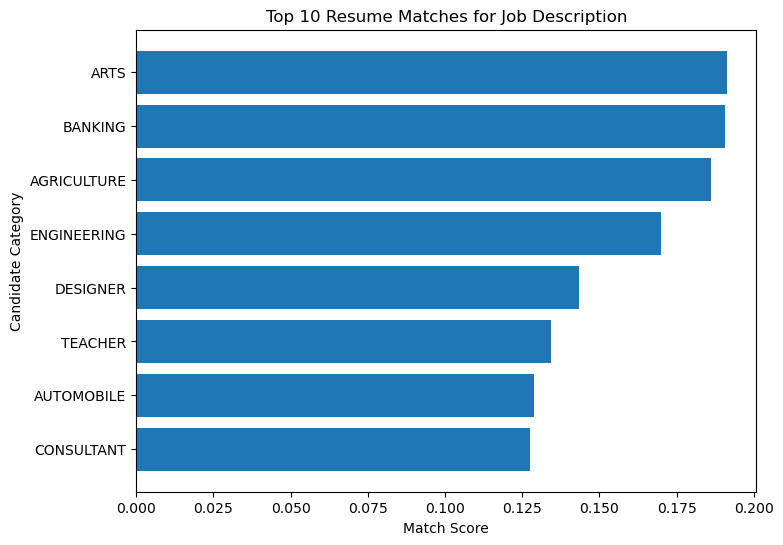

In [37]:
import matplotlib.pyplot as plt

# Select top 10 candidates
top10 = ranked_candidates.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10['Category'], top10['Match_Score'])

plt.xlabel("Match Score")
plt.ylabel("Candidate Category")
plt.title("Top 10 Resume Matches for Job Description")

plt.gca().invert_yaxis()

plt.show()

The bar chart shows the top 10 resumes ranked by similarity score
with the job description.

Higher match scores indicate resumes that contain more relevant
skills and keywords required for the job role.

This visualization helps recruiters quickly identify the most
suitable candidates.

In [39]:
top5 = ranked_candidates[['Category','Match_Score']].head(5)

top5

,Category,Match_Score
2291,ARTS,0.191230
2153,BANKING,0.190519
926,AGRICULTURE,0.186159
1762,ENGINEERING,0.169943
194,DESIGNER,0.143523


In [40]:
top5 = ranked_candidates[['Category','Match_Score']].head(5)

top5['Rank'] = range(1, len(top5)+1)

top5 = top5[['Rank','Category','Match_Score']]

top5

,Rank,Category,Match_Score
2291,1,ARTS,0.191230
2153,2,BANKING,0.190519
926,3,AGRICULTURE,0.186159
1762,4,ENGINEERING,0.169943
194,5,DESIGNER,0.143523


In [41]:
top_candidates = ranked_candidates[['Category','Match_Score','Missing_Skills']].head(5)

top_candidates

KeyError: "['Missing_Skills'] not in index"